In [ ]:
from implementations.london_graph import LondonTubeGraph
from implementations.modified_dijkstra import dijkstra
from implementations.a_star import a_star
import time
import numpy as np
import random
import matplotlib.pyplot as plt

# initialise our graph, load stations/connections
graph = LondonTubeGraph()
graph.load_stations("data/london_stations.csv")
graph.load_connections("data/london_connections.csv")

# max_speed, best_pair = graph.calculate_max_speed()
# print(f"""Maximum network speed is {max_speed}km / m, found from {best_pair[0]} to {best_pair[1]} (line: {best_pair[2]}). 
#       Our heuristic for station 1 to 52 is {graph.calculate_heuristic(1,52,max_speed)}""")
# create heuristic dict

# for k, h in h_mapped.items():
#     print(h)

pred, path = a_star(graph, 256, 158, h_mapped[256])
print(path)

graph.print_station(256)
graph.print_station(88)
graph.print_station(68)

[256, 68, 158]
[256] Theydon Bois (Zone 6.0)
  -> to Debden (ID: 68) | Time: 3 mins | Line ID: 2
  -> to Epping (ID: 88) | Time: 2 mins | Line ID: 2
[88] Epping (Zone 6.0)
  -> to Theydon Bois (ID: 256) | Time: 2 mins | Line ID: 2
[68] Debden (Zone 6.0)
  -> to Loughton (ID: 158) | Time: 2 mins | Line ID: 2
  -> to Theydon Bois (ID: 256) | Time: 3 mins | Line ID: 2


Completed tests


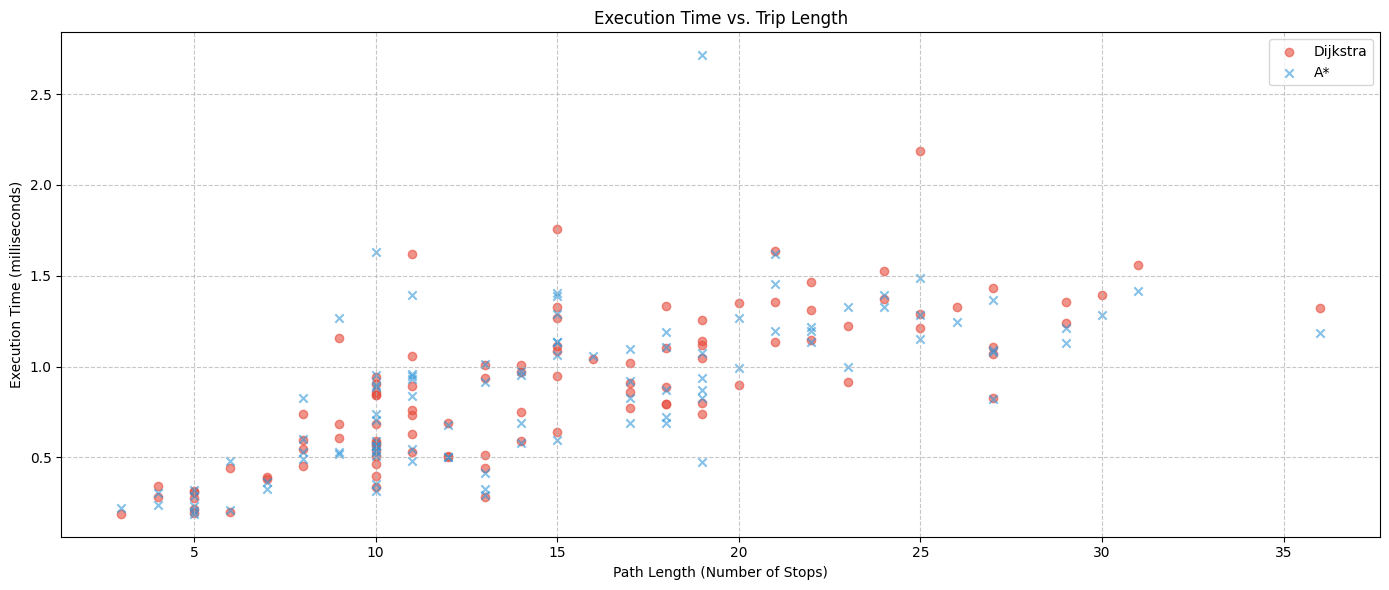

In [ ]:
# EXPERIMENT 1: Testing on pairs of 2 randomly chosen stations
# NOTE: for fair testing, we slightly modify Dijkstra for point ot point, instead of all paths

G = LondonTubeGraph()
G.load_stations("data/london_stations.csv")
G.load_connections("data/london_connections.csv")

def test_suite1(G, tests = 100):
    heuristic_dicts = G.create_heuristic_dict()
    stations = list(G.station_info.keys())

    dijkstra_times = []
    a_star_times = []
    path_lengths = []

    #  print

    for _ in range(tests):
        # two randomly selected stations to test, s != d
        s, d = random.sample(stations, 2)

        start_time = time.perf_counter()
        _, d_path = dijkstra(G, s, d)
        d_time = (time.perf_counter() - start_time) * 1000

        start_time = time.perf_counter()
        _, a_path = a_star(G, s, d, heuristic_dicts[s])
        a_time = (time.perf_counter() - start_time) * 1000

        # store valid results
        if len(d_path) > 0:
            dijkstra_times.append(d_time)
            
            a_star_times.append(a_time)
            
            # Use the length of the path as a proxy for "trip distance"
            path_lengths.append(len(d_path))
    print("Completed tests")
    generate_plot(dijkstra_times,a_star_times,path_lengths)

def generate_plot(d_times, a_times, lengths):
    """
    Scatter plot for Time. """ 

    fig, ax2 = plt.subplots(figsize=(14, 6))
    
    # Execution Time vs. Path Length
    ax2.scatter(lengths, d_times, color='#e74c3c', alpha=0.6, label='Dijkstra', marker='o')
    ax2.scatter(lengths, a_times, color='#3498db', alpha=0.6, label='A*', marker='x')
    
    ax2.set_title('Execution Time vs. Trip Length')
    ax2.set_xlabel('Path Length (Number of Stops)')
    ax2.set_ylabel('Execution Time (milliseconds)')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

test_suite1(G, 100)